### Outcome Based Metric Plots

In this notebook we're collecting statistics for the rollouts of experiment 13 and provide visualizations.

1) plot the pass@k curves
2) plot initial solverate versus final solverate

In [1]:
outcome_based_plotdir = "/u/rfechner/verl/plots/outcome_based"

In [2]:
import os
import pickle
import pathlib
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from util import rollouts, qw7_rollouts, model_marker_mapper, method_color_mapper, model_name_mapper, method_name_mapper

In [3]:
# Enable LaTeX for all text
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
})

In [4]:
passk = rollouts(recompute=False)
passk_qw = qw7_rollouts(recompute=False)
del passk_qw['qwen2.5_7b__entropy_reg']

Reading Experiment 13 + selective Qwen2.5-7B rollouts.
Reading Qwen2.5-7B rollouts


In [5]:
models = set([x.split('__')[0] for x in passk.keys()])
methods = set([x.split('__')[1] for x in passk.keys()])

qw_models = set([x.split('__')[0] for x in passk_qw.keys()])
qw_methods = set([x.split('__')[1] for x in passk_qw.keys()])

models, methods

({'eurollm_9b_instruct',
  'llama_3.1_8b_instruct',
  'qwen2.5_1.5b',
  'qwen2.5_7b'},
 {'grpo-passk', 'grpo-s', 'gspo', 'kl-cov'})

In [6]:
# we have to correct for the base model archiving different pass@k values. In this analysis we'll just take the first estimate.
base_model_mapper = {model : None for model in models}
for method in passk.keys():
    m = method.split('__')[0]
    if base_model_mapper[m] is None:
        base_model_mapper[m] = passk[method]['0']
    

    assert all([
        np.allclose(base_model_mapper[m][k], passk[method]['0'][k]) for k in passk[method]['0'].keys()
    ])

base_model_mapper = {model : None for model in qw_models}
for method in passk_qw.keys():
    m = method.split('__')[0]
    if base_model_mapper[m] is None:
        base_model_mapper[m] = passk_qw[method]['0']
    

    assert all([
        np.allclose(base_model_mapper[m][k], passk_qw[method]['0'][k]) for k in passk_qw[method]['0'].keys()
    ])


In [7]:
def plot_pass_rates(passrates_per_method, filter_datasets : None | list[str]=None):
    methods = list(passrates_per_method.keys())
    n_methods = len(methods)

    # Collect all dataset names (validation data sources)
    datasets = sorted({
        ds for method_data in passrates_per_method.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    if filter_datasets:
        datasets = list(filter(lambda x: x in filter_datasets, datasets))

    n_datasets = len(datasets)

    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(3 * n_methods, 3 * n_datasets),
        sharey='row',
        squeeze=False
    )

    for j, method in enumerate(methods):
        method_data = passrates_per_method[method]

        # Collect all checkpoints and sort numerically
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        n_ckpts = len(checkpoints)
        cmap = plt.get_cmap("viridis")
        colors = [cmap(i / max(1, n_ckpts - 1)) for i in range(n_ckpts)]

        # first color should be bright red to clearly make out base model passk
        colors[0] = 'red'

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            for color, ckpt in zip(colors, checkpoints):
                if dataset not in method_data[ckpt]:
                    continue
                y = np.array(method_data[ckpt][dataset]).mean(axis=0) # mean over all questions
                x = np.arange(1, len(y) + 1)
                ax.plot(x, y, color=color, label=f"ckpt {ckpt}")
            if i == 0:
                mo, me = method.split('__')
                ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{dataset}\npass@k")

            ax.set_xticks(x, 2**np.arange(9), fontsize=8, rotation=75)
            ax.set_xlabel("k")
            ax.grid(True, alpha=0.3)

            if i == 0:
                # Only show legend once for clarity
                ax.legend(fontsize=8, title="Checkpoint", loc='upper left')

    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pass_at_kplots__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}__Datasets:{'all' if not filter_datasets else '--'.join(datasets)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

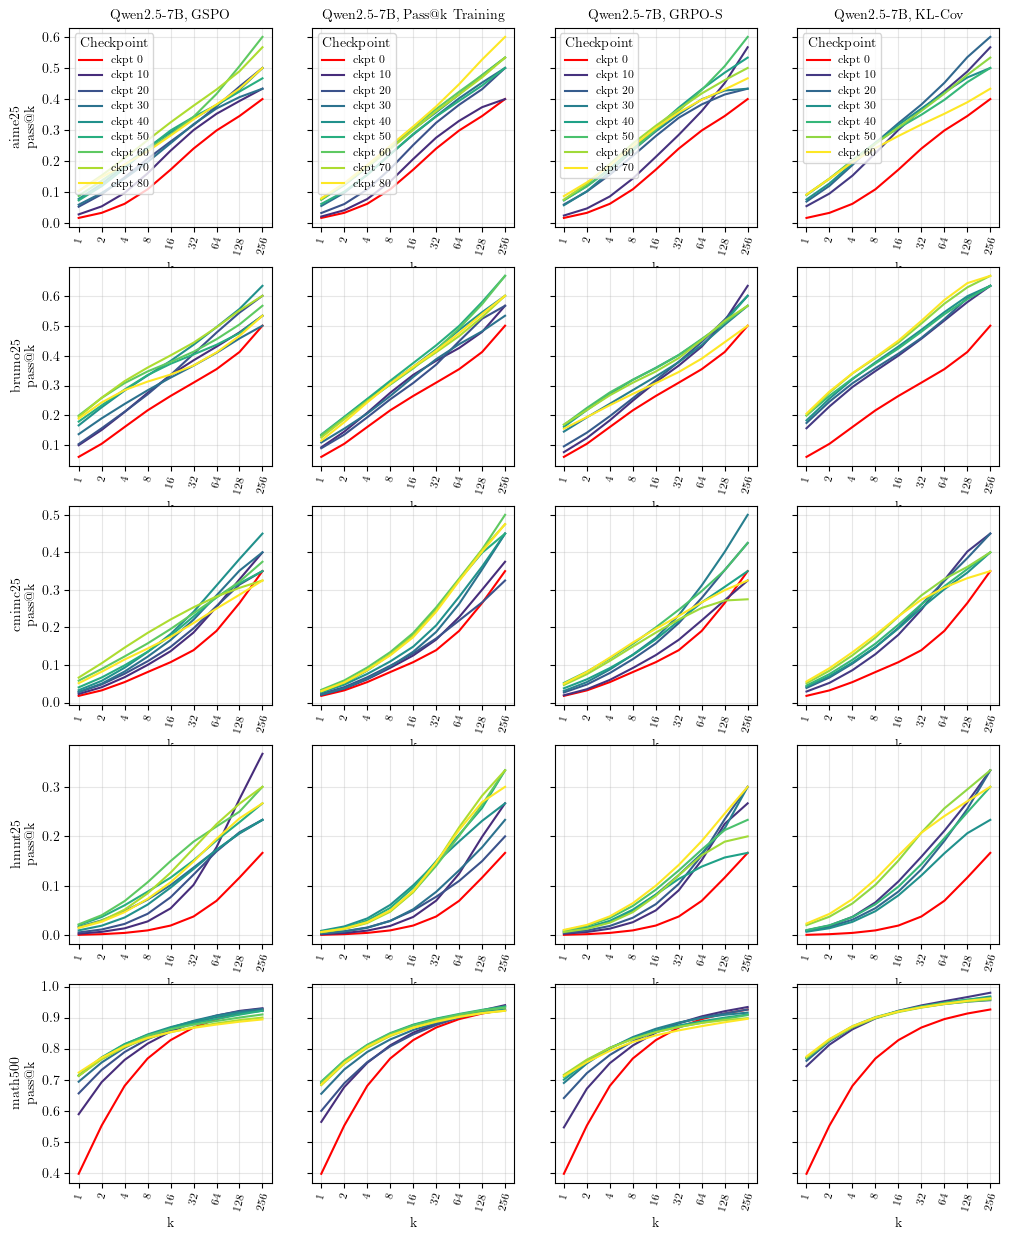

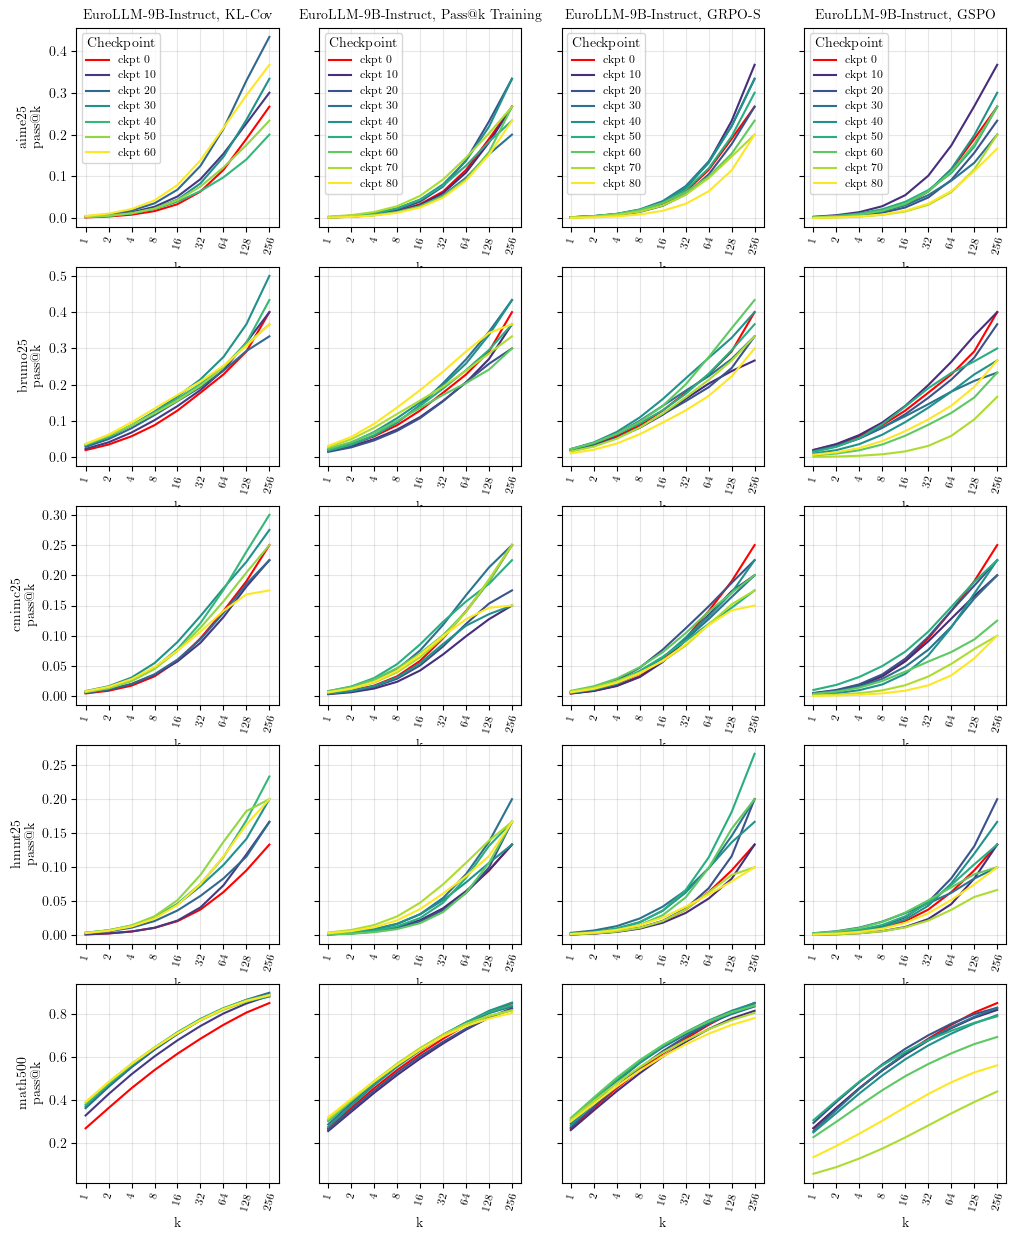

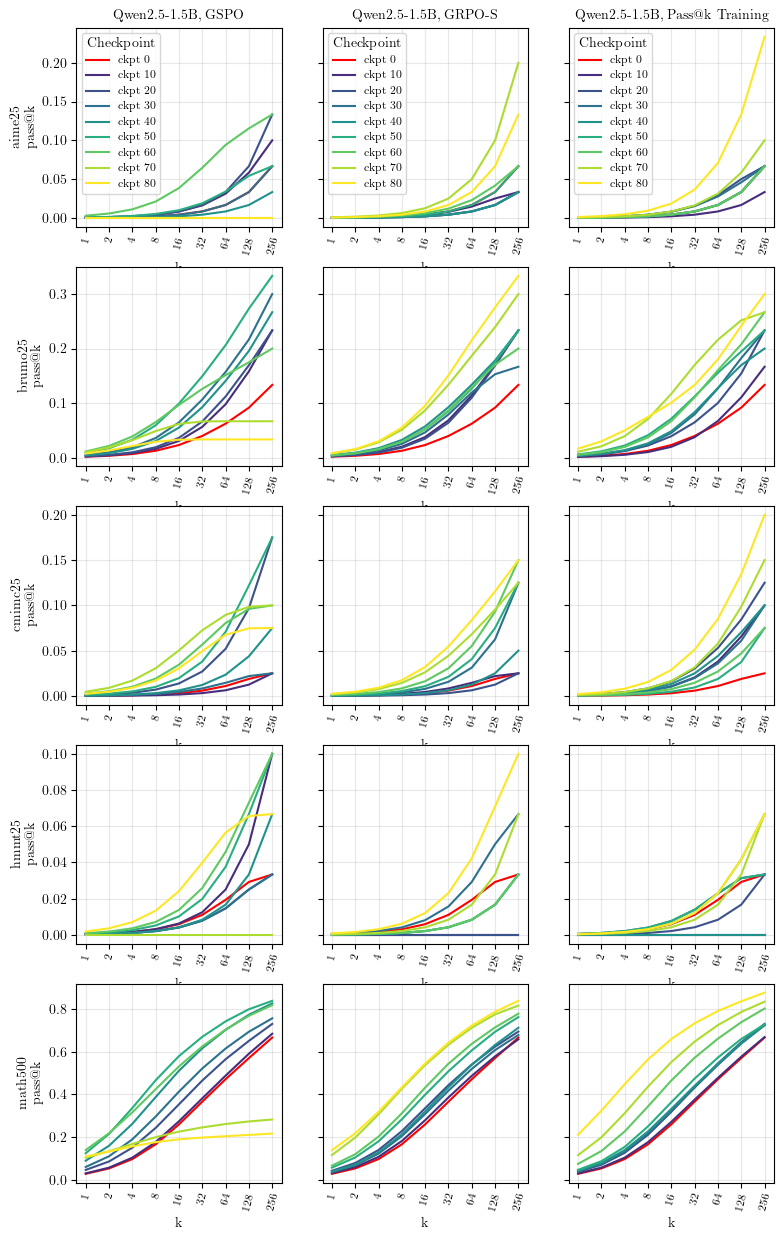

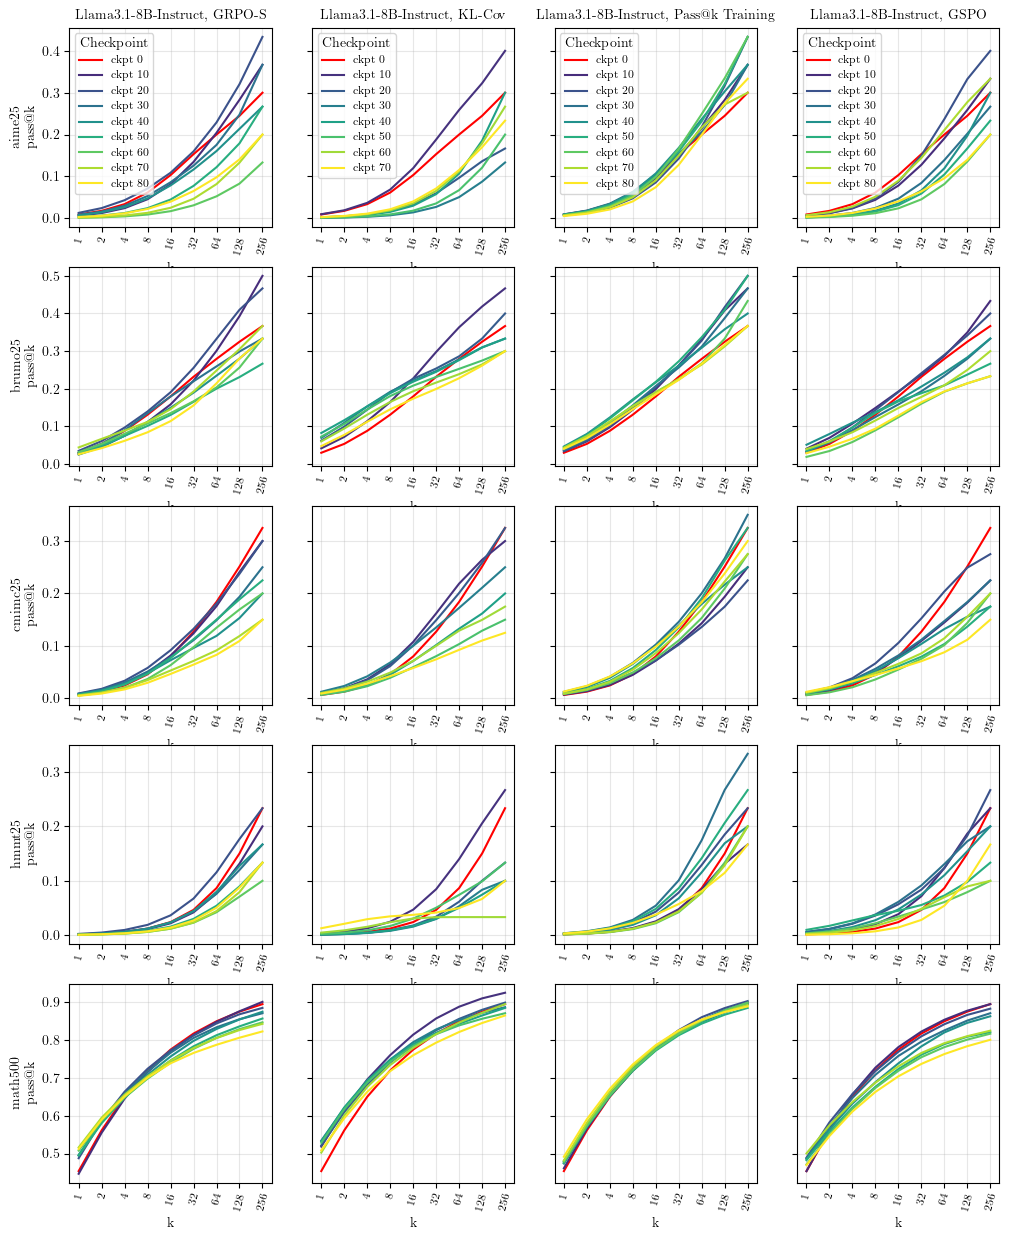

In [8]:
for m in models:
    plot_pass_rates({k : v for k,v in passk.items() if m in k})

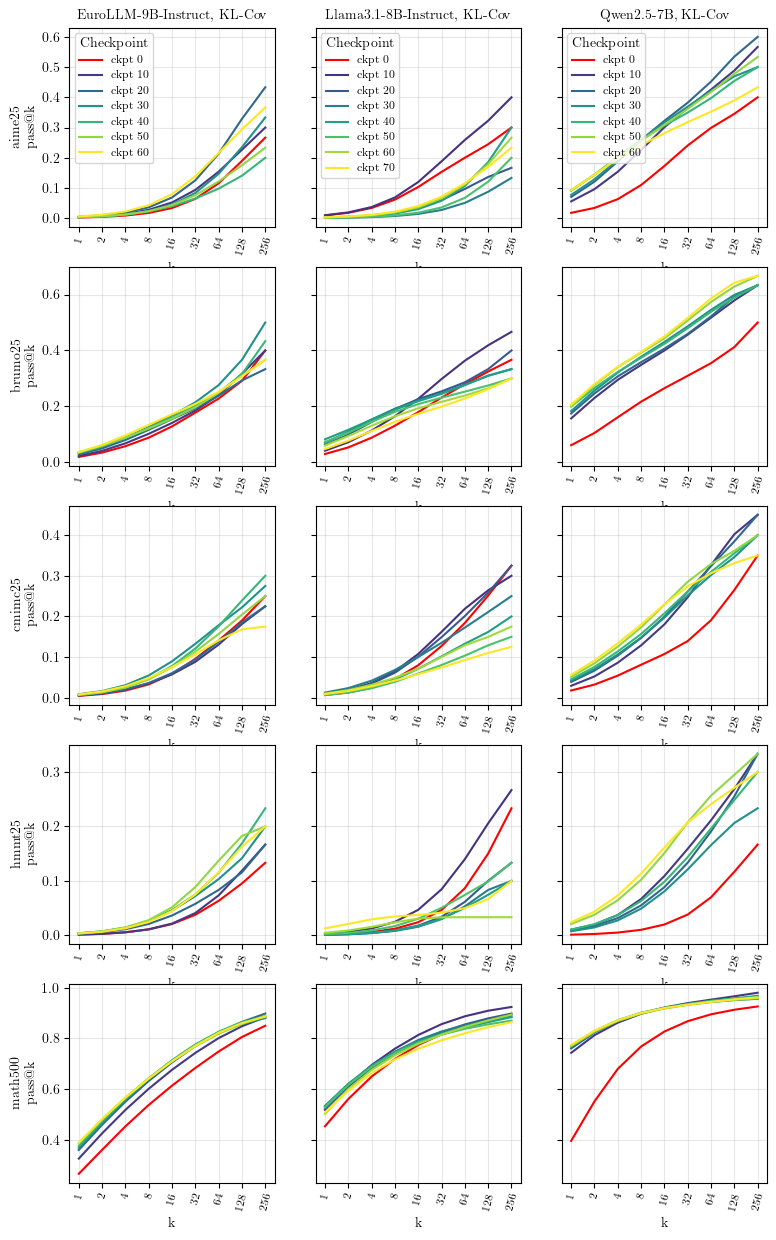

In [9]:
# Plots for Results Section on KL-Cov.
subset = {k : v for k,v in passk.items() if 'kl-cov' in k}
plot_pass_rates(subset)

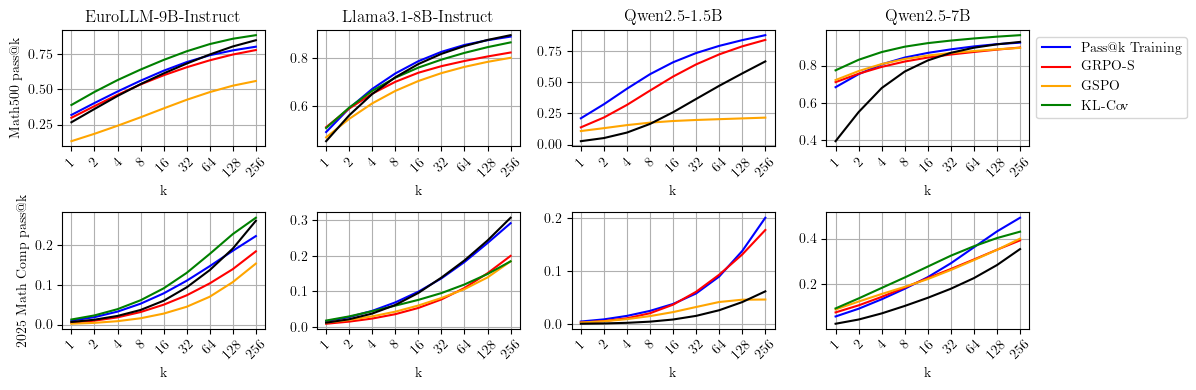

In [19]:
def klcov_comparison_plot(passrates_per_method):    
    keys = list(passrates_per_method.keys())
    models, methods = zip(*[k.split('__') for k in keys])
    models, methods = sorted(list(set(models))), sorted(list(set(methods)))
    
    fig, axes = plt.subplots(nrows=2, 
                             ncols=len(models), 
                             figsize=(len(models) * 3, 4))
    
    math500_axes = axes[0, :]
    other_axes = axes[1, :]

    for i, (ax, model) in enumerate(zip(math500_axes, models)):
        
        if i == 0:
            ax.set_ylabel('Math500 pass@k')
        ax.set_title(model_name_mapper[model])
        for method in methods:
            key = model + '__' + method
            if key not in passrates_per_method:
                continue
            
            last_checkpoint = sorted([int(k) for k in passrates_per_method[key].keys()])[-1]
            ax.plot(passrates_per_method[key][str(last_checkpoint)]['math500'].mean(axis=0), 
                    label=method_name_mapper[method], color=method_color_mapper[method])

        # base model
        if i == len(models) - 1:
            ax.legend(bbox_to_anchor=[1, 1])
            
        basemodel_key = model + '__' + 'gspo'
        ax.plot(passrates_per_method[basemodel_key]['0']['math500'].mean(axis=0), label='base', color=method_color_mapper['base'])
        ax.set_xticks(np.arange(9), 2**np.arange(9), rotation=45)
        ax.set_xlabel('k')
        ax.grid()
        
    for i, (ax, model) in enumerate(zip(other_axes, models)):
        
        if i == 0:
            ax.set_ylabel('2025 Math Comp pass@k')

        for method in methods:

            # collect pass@k values to average.
            passk_values = []
            key = model + '__' + method
            if key not in passrates_per_method:
                continue

            last_checkpoint = sorted([int(k) for k in passrates_per_method[key].keys()])[-1]
            passk_values = np.concat(
                [v for k, v in passrates_per_method[key][str(last_checkpoint)].items() if k not in ['math500']], axis=0)
            ax.plot(passk_values.mean(axis=0), label=method_name_mapper[method], color=method_color_mapper[method])

        # base model
        basemodel_key = model + '__' + 'gspo'
        passk_values = np.concat(
            [v for k, v in passrates_per_method[basemodel_key]['0'].items() if k not in ['math500']], axis=0)
        ax.plot(passk_values.mean(axis=0), label='base', color=method_color_mapper['base'])
        ax.set_xticks(np.arange(9), 2**np.arange(9), rotation=45)
        ax.set_xlabel('k')
        ax.grid()

    fig.tight_layout()
    outfile = f"passk_comparison_highlevel.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

klcov_comparison_plot(passk)


['grpo', 'grpo-passk', 'dapo', 'drgrpo', 'clip-cov', 'kl-cov', 'grpo-s', 'gtpo', 'gspo']


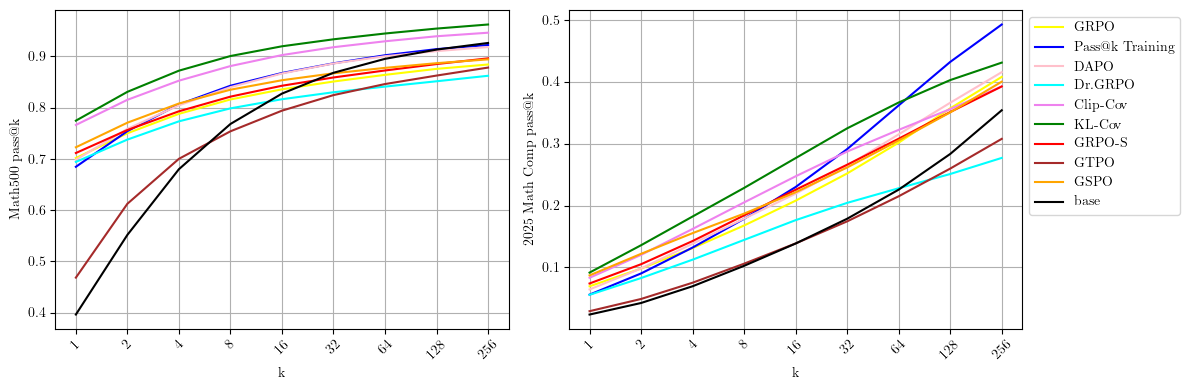

In [11]:
### Only Qwen2.5-7B Plots: one row, two columns: One Math500, the other 2025 math competitions
def qwen7_comparison_plot(qw_passk):    
    keys = list(qw_passk.keys())
    models, methods = zip(*[k.split('__') for k in keys])
    models, methods = list(set(models)), list(set(methods))
    
    print(methods)
    methods_color_mapper = {m  : c for m, c in zip(methods, ['blue', 'red', 'yellow', 'green', 'lightblue', 'pink', 'cyan', 'orange', 'lightgreen'])}
    methods_color_mapper.update({'base' : 'black'})

    fig, axes = plt.subplots(nrows=1, 
                             ncols=2, 
                             figsize=(12, 4))
    axes = axes.flatten()
    math500_axis = axes[0]
    other_axis = axes[1]

    math500_axis.set_ylabel('Math500 pass@k')
    for method in methods:
        key = "qwen2.5_7b" + '__' + method
        if key not in qw_passk:
            continue
        
        last_checkpoint = sorted([int(k) for k in qw_passk[key].keys()])[-1]
        math500_axis.plot(qw_passk[key][str(last_checkpoint)]['math500'].mean(axis=0), label=method, color=method_color_mapper[method])

    # base model
    math500_axis.plot(qw_passk[key]['0']['math500'].mean(axis=0), label='base', color=method_color_mapper['base'])
    math500_axis.set_xticks(np.arange(9), 2**np.arange(9), rotation=45)
    math500_axis.set_xlabel('k')
    math500_axis.grid()
    
    
    other_axis.set_ylabel('2025 Math Comp pass@k')
    for method in methods:

        # collect pass@k values to average.
        passk_values = []
        key = 'qwen2.5_7b' + '__' + method
        if key not in qw_passk:
            continue

        last_checkpoint = sorted([int(k) for k in qw_passk[key].keys()])[-1]
        passk_values = np.concat(
            [v for k, v in qw_passk[key][str(last_checkpoint)].items() if k not in ['math500']], axis=0)
        other_axis.plot(passk_values.mean(axis=0), label=method_name_mapper[method], color=method_color_mapper[method])

    # base model
    passk_values = np.concat(
        [v for k, v in qw_passk[key]['0'].items() if k not in ['math500']], axis=0)
    other_axis.plot(passk_values.mean(axis=0), label='base', color=method_color_mapper['base'])

    other_axis.legend(bbox_to_anchor=[1, 1])

    other_axis.set_xticks(np.arange(9), 2**np.arange(9), rotation=45)
    other_axis.set_xlabel('k')
    other_axis.grid()
    fig.tight_layout()
    
    outfile = f"qw7_passk_comparison_highlevel.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)



qwen7_comparison_plot(passk_qw)

In [12]:
# def integrated_passk(values):
#     """
#     values: array shaped [num_tasks, num_k]
#     returns scalar integrated pass@k
#     """
#     return values.mean(axis=0).sum()

# def klcov_training_gain_barplot(passrates_per_method):

#     keys = list(passrates_per_method.keys())
#     models, methods = zip(*[k.split('__') for k in keys])
#     models, methods = sorted(set(models)), sorted(set(methods))

#     methods_color_mapper = {
#         m: c for m, c in zip(methods, ['blue', 'red', 'green', 'orange'])
#     }

#     fig, axes = plt.subplots(
#         nrows=2,
#         ncols=2,
#         figsize=(4 * len(models), 6),
#         sharey='row'
#     )

#     row_defs = [
#         ('math500', 'Math500'),
#         ('other', '2025 Math Comp')
#     ]

#     col_defs = [
#         ('0_to_10', 'pass@k of cp 10 − pass@k of cp 0'),
#         ('10_to_last', 'pass@k of final model − pass@k of cp 10')
#     ]

#     bar_width = 0.8 / len(methods)
#     x = np.arange(len(models))

#     for row_idx, (dataset_key, row_title) in enumerate(row_defs):
#         for col_idx, (phase, col_title) in enumerate(col_defs):

#             ax = axes[row_idx, col_idx]

#             for m_idx, method in enumerate(methods):
#                 gains = []

#                 for model in models:
#                     key = f"{model}__{method}"
#                     if key not in passrates_per_method:
#                         gains.append(np.nan)
#                         continue

#                     ckpts = sorted(int(k) for k in passrates_per_method[key].keys())
#                     ckpt0 = '0'
#                     ckpt10 = '10'
#                     ckpt_last = str(ckpts[-1])

#                     def collect(dataset, ckpt):
#                         if dataset == 'math500':
#                             return passrates_per_method[key][ckpt]['math500']
#                         else:
#                             return np.concatenate(
#                                 [v for k, v in passrates_per_method[key][ckpt].items()
#                                  if k not in ['math500', 'aime25']],
#                                 axis=0
#                             )

#                     if phase == '0_to_10':
#                         v0 = integrated_passk(collect(dataset_key, ckpt0))
#                         v1 = integrated_passk(collect(dataset_key, ckpt10))
#                         gains.append(v1 - v0)
#                     else:
#                         v0 = integrated_passk(collect(dataset_key, ckpt10))
#                         v1 = integrated_passk(collect(dataset_key, ckpt_last))
#                         gains.append(v1 - v0)

#                 ax.bar(
#                     x + m_idx * bar_width,
#                     gains,
#                     width=bar_width,
#                     color=methods_color_mapper[method],
#                     label=method if (row_idx == 0 and col_idx == 1) else None
#                 )

#             ax.axhline(0, color='black', linewidth=0.8)
#             ax.set_xticks(x + bar_width * (len(methods) - 1) / 2)
#             ax.set_xticklabels(models, rotation=30)
#             ax.set_title(col_title if row_idx == 0 else "")

#             if col_idx == 0:
#                 ax.set_ylabel(f"{row_title}\nΔ integrated pass@k")

#             ax.grid(axis='y')

#     axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     fig.tight_layout()
#     fig.suptitle('Integrated gain over the courses of RL', y=1.04, fontsize=15)
#     outfile = "passk_integrated_gains_barplot.pdf"
#     fig.savefig(os.path.join(outcome_based_plotdir, outfile), bbox_inches="tight")
    
#     plt.show()

#     plt.close(fig)

# klcov_training_gain_barplot(passk)

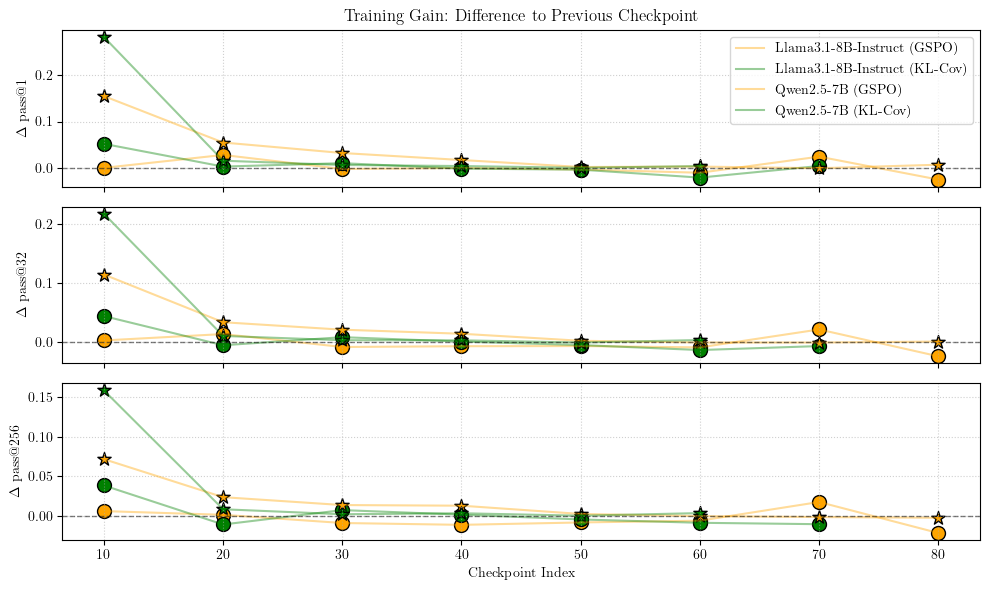

In [13]:
def klcov_checkpoint_delta_plot(passrates_per_method):
    keys = list(passrates_per_method.keys())
    models_raw, methods = zip(*[k.split('__') for k in keys])
    models, methods = sorted(set(models_raw)), sorted(set(methods))
    
    # Konfiguration der Metriken
    ks = [1, 32, 256]
    # Falls dein Array [num_tasks, 3] ist, nutze 0, 1, 2. 
    # Falls es mehr k-Werte enthält, passe die Indizes hier an:
    k_indices = {1: 0, 32: 1, 256: 2} 

    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 6), sharex=True)
    
    for row_idx, k_val in enumerate(ks):
        ax = axes[row_idx]
        k_idx = k_indices[k_val]
        
        for model in models:
            for method in methods:
                key = f"{model}__{method}"
                if key not in passrates_per_method:
                    continue
                
                # Checkpoints numerisch sortieren
                ckpt_str_keys = sorted(passrates_per_method[key].keys(), key=lambda x: int(x))
                ckpt_ints = [int(c) for c in ckpt_str_keys]
                
                def get_val(c_str):
                    # Mittelwert über alle Tasks für den spezifischen k-Index
                    data = np.concat(list(passrates_per_method[key][c_str].values()), axis=0)
                    return data.mean(axis=0)[k_idx]

                # Berechne Differenz zum jeweils vorherigen Checkpoint
                deltas = []
                x_labels = []
                
                for i in range(1, len(ckpt_ints)):
                    current_val = get_val(ckpt_str_keys[i])
                    prev_val = get_val(ckpt_str_keys[i-1])
                    deltas.append(current_val - prev_val)
                    x_labels.append(ckpt_ints[i])

                ax.plot(
                    x_labels, 
                    deltas, 
                    label=f"{model_name_mapper[model]} ({method_name_mapper[method]})" if row_idx == 0 else None,
                    color=method_color_mapper[method],
                    linestyle='-',
                    alpha=0.4,
                )
                ax.scatter(
                    x_labels,
                    deltas,
                    color=method_color_mapper[method],
                    edgecolor='black',
                    linewidths=1,
                    marker = model_marker_mapper[model],
                    s=100
                )

        ax.set_ylabel(f"$\Delta$ pass@{k_val}")
        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(True, linestyle=':', alpha=0.6)

    axes[0].set_title("Training Gain: Difference to Previous Checkpoint")
    axes[-1].set_xlabel("Checkpoint Index")
    axes[0].legend(loc='upper right')
    
    fig.tight_layout()
    outfile = "passk_step_deltas.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), bbox_inches="tight")
    plt.show()
subset = {k : v for k, v in passk.items() if (any(m in k for m in ['kl-cov', 'gspo']) and any(mo in k for mo in ['qwen2.5_7b', 'llama']))}
klcov_checkpoint_delta_plot(subset)

In [26]:
def plot_final_delta_histograms(per_question_passrates, passat_value=1, bins=30):
    """
    Plot histograms of per-question passrate changes between first and last checkpoint,
    per method and per dataset, with consistent bins across all subplots.
    
    Args:
        per_question_passrates: dict[method][checkpoint][dataset] -> np.array of per-question pass rates
        bins: int, number of histogram bins
    """
    methods = list(per_question_passrates.keys())
    n_methods = len(methods)

    # Collect all dataset names
    datasets = sorted({
        ds for method_data in per_question_passrates.values()
        for ckpt_data in method_data.values()
        for ds in ckpt_data.keys()
    })
    n_datasets = len(datasets)
    passat_index = int(np.log2(passat_value)) # 1 -> 0, 2 -> 1, 4 -> 2, ...

    # Compute global min/max Δ for consistent binning
    all_deltas = []
    for method in methods:
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]
        for dataset in datasets:
            if dataset in method_data.get(first_ckpt, {}) and dataset in method_data.get(last_ckpt, {}):
                first_passrates, last_passrates = method_data[first_ckpt][dataset][:, passat_index], method_data[last_ckpt][dataset][:, passat_index]
                delta = last_passrates - first_passrates
                delta = np.clip(delta, -1, 1)
                all_deltas.append(delta)
    if len(all_deltas) == 0:
        print("No data available to plot")
        return
    all_deltas = np.concatenate(all_deltas)
    vmin, vmax = all_deltas.min(), all_deltas.max()

    # Create subplots
    fig, axes = plt.subplots(
        n_datasets, n_methods,
        figsize=(3 * n_methods, 3 * n_datasets),
        squeeze=False,
        sharex=True,
        sharey=False
    )

    for j, method in enumerate(methods):
        method_data = per_question_passrates[method]
        checkpoints = sorted(method_data.keys(), key=lambda x: int(x))
        first_ckpt = checkpoints[0]
        last_ckpt = checkpoints[-1]

        for i, dataset in enumerate(datasets):
            ax = axes[i, j]

            if dataset not in method_data.get(first_ckpt, {}) or dataset not in method_data.get(last_ckpt, {}):
                ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
                continue

            first_passrates, last_passrates = method_data[first_ckpt][dataset][:, passat_index], method_data[last_ckpt][dataset][:, passat_index]
            delta = last_passrates - first_passrates
            delta = np.clip(delta, -1, 1)
            mean_delta = np.mean(delta)

            # Custom colored histogram: separate negative and positive bins
            counts, bin_edges = np.histogram(delta, bins=bins, range=(vmin, vmax))

            for k in range(len(counts)):
                left = bin_edges[k]
                right = bin_edges[k+1]
                center = 0.5 * (left + right)

                if center < 0:
                    color = "red"
                elif center > 0:
                    color = "green"
                else:
                    color = "gray"

                ax.bar(center, counts[k],
                    width=(right - left),
                    align='center',
                    color=color,
                    edgecolor='black',
                    alpha=0.3)

            # Plot vertical line for mean
            line = ax.axvline(mean_delta, color='black', alpha=0.8, linewidth=1)

            # Add legend with mean
            ax.legend([line], [f'Mean: {mean_delta:.2f}'], fontsize=8)
            mo, me = method.split('__')
            ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}" if i==0 else "", fontsize=10)
            if j == 0:
                ax.set_ylabel(f"{dataset}\nCount")
            ax.set_xlabel(rf"$\Delta$ pass@{passat_value} (last - first)")
            ax.grid(True, alpha=0.3)

    plt.suptitle(rf"Per-question $\Delta$ (last - first) pass@{passat_value} histograms", fontsize=16, y=1.02)
    plt.tight_layout()

    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pass_at_{passat_value}_hist__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

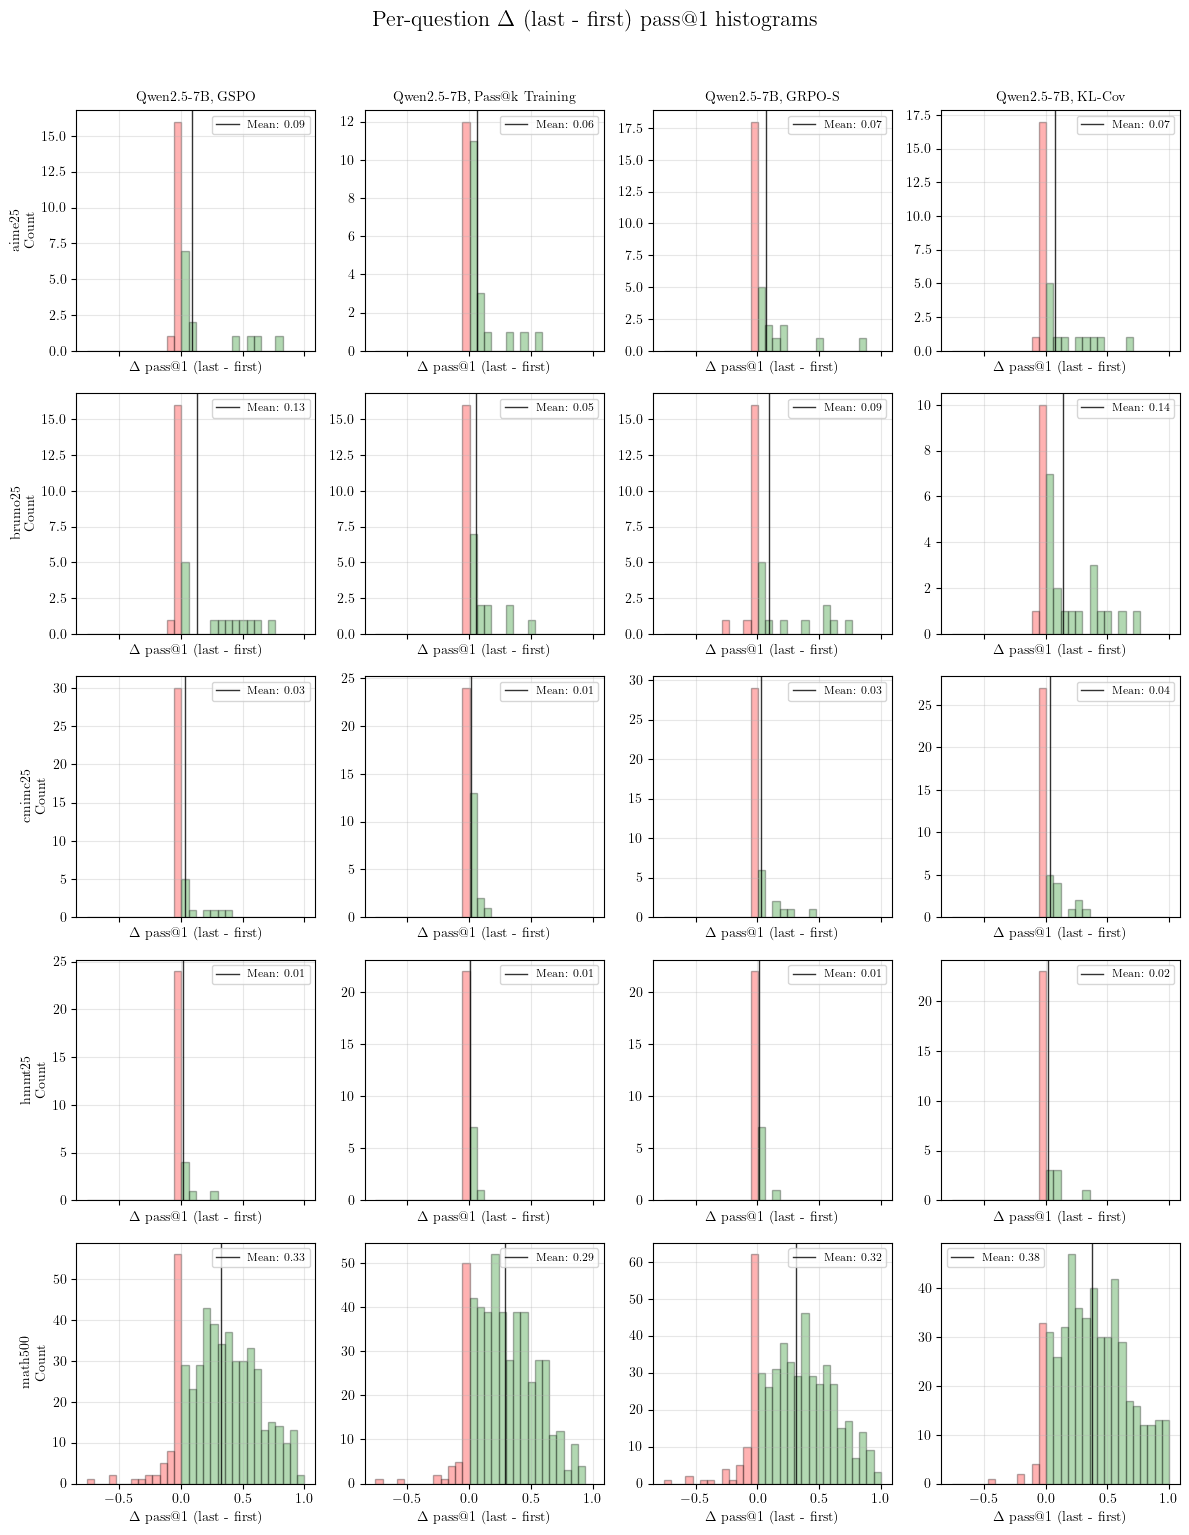

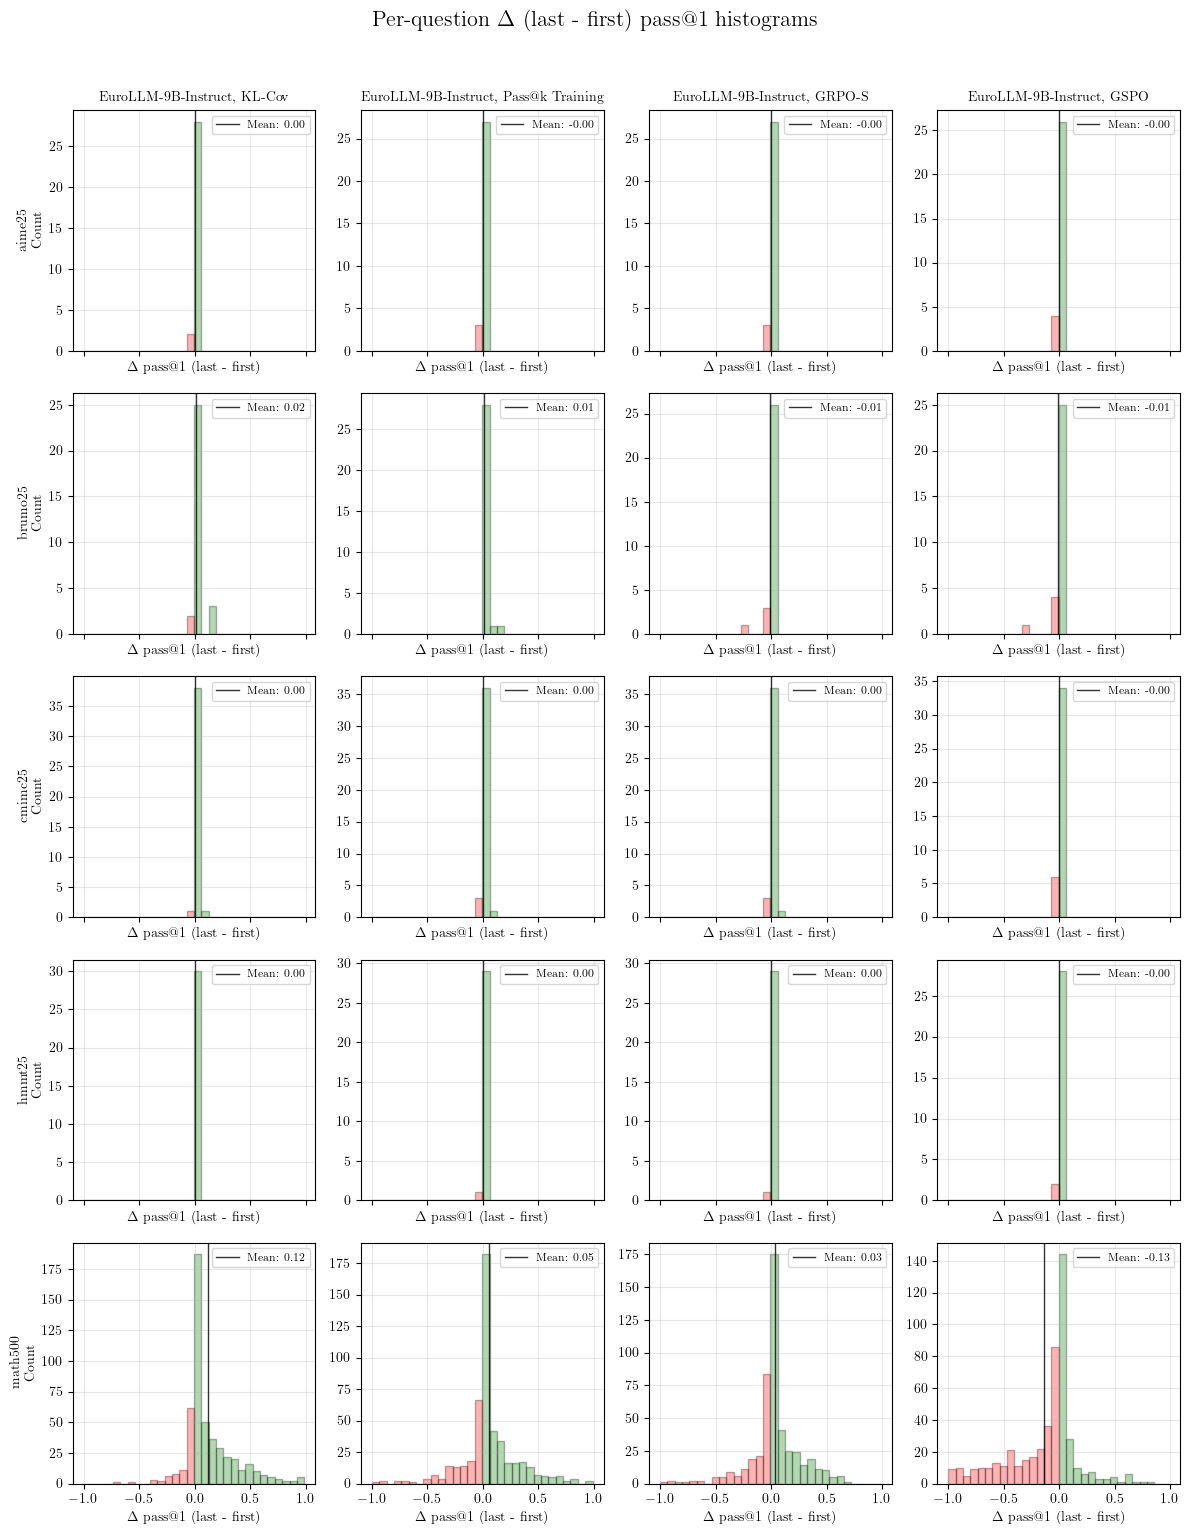

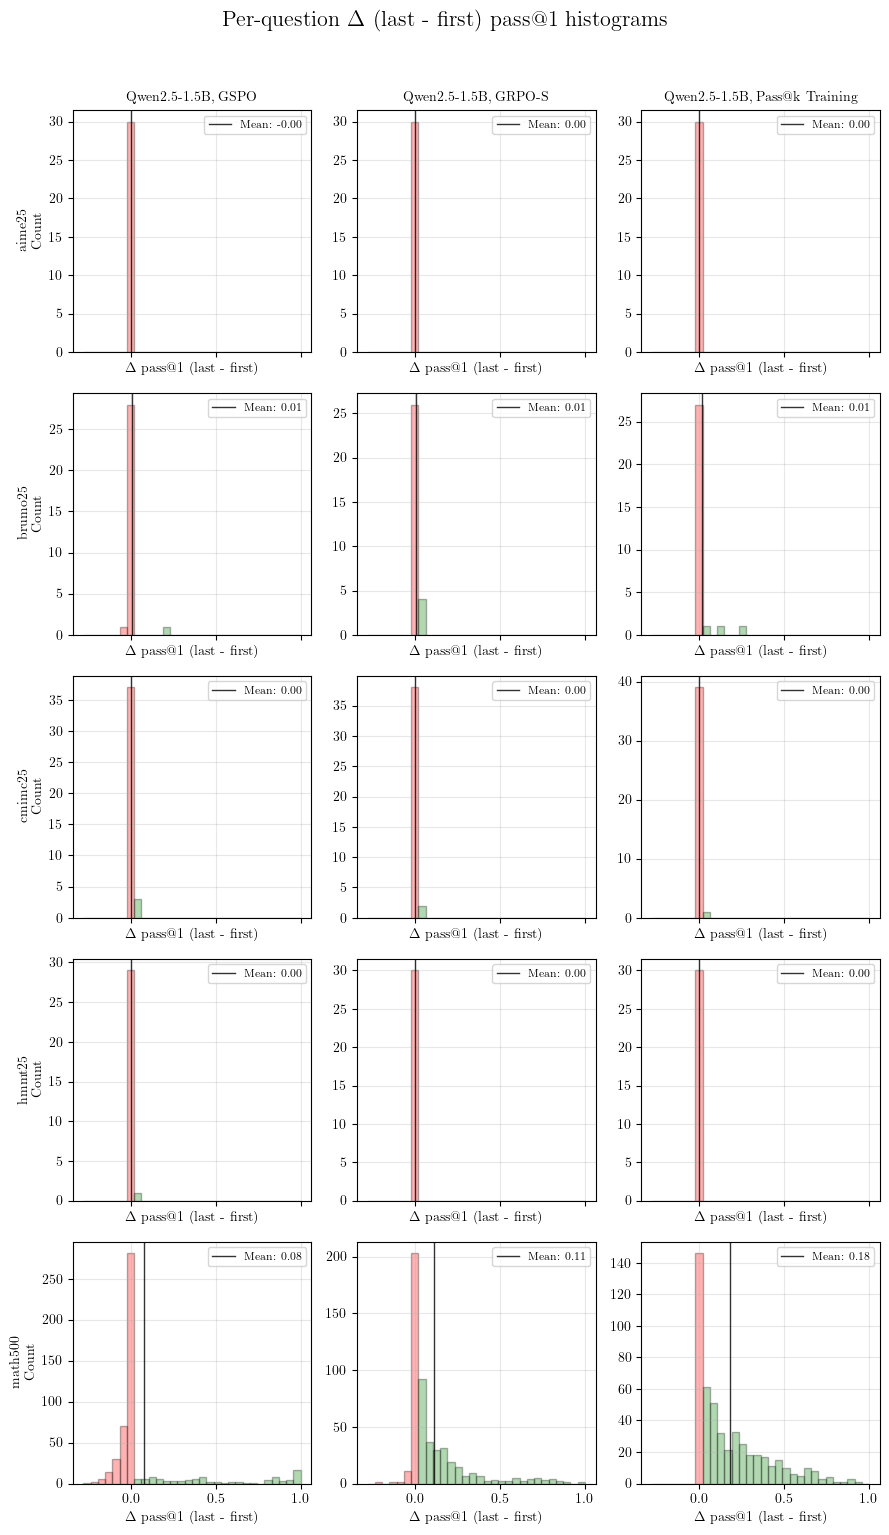

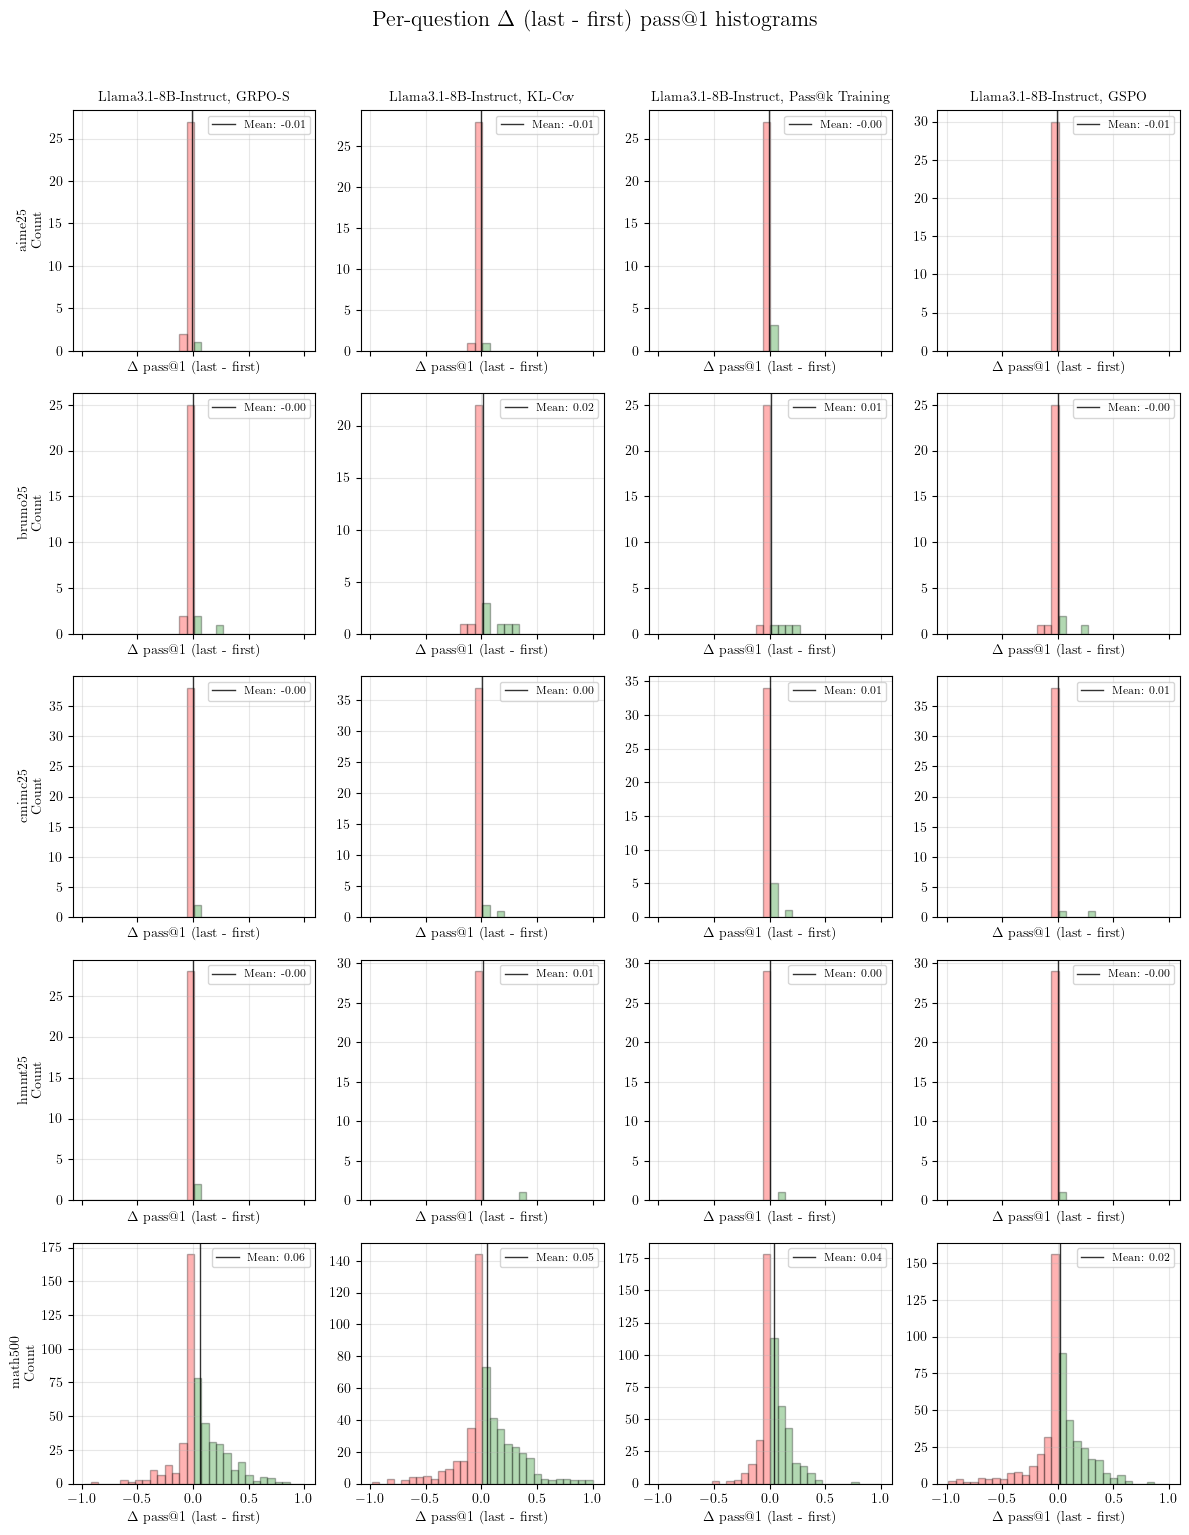

In [27]:
for m in models:
    plot_final_delta_histograms({k : v for k,v in passk.items() if m in k}, passat_value=1)

In [28]:
# preservation/shrinkage/expansion tables.
def compute_PSE(subset : dict) -> dict:
    """
        Computes Preservation, Shrinkage and Expansion for all checkpoints. We're comparing against the base model
        and against the previous checkpoint to uncover training dynamics.
    """

    ret = {}
    for key, checkpoints in subset.items():
        base_pass256 = {dataset_name : passk_values[:, -1].astype(bool) for dataset_name, passk_values in checkpoints['0'].items()}
        ret[key] = {}
        for i_str, passk_values in checkpoints.items():
            if i_str == '0':
                prev_pass256 = base_pass256
                continue
            ret[key][i_str] = {}

            cur_pass256 = {dataset_name : passk_values[:, -1].astype(bool) for dataset_name, passk_values in passk_values.items()}
            for dataset_name, cur_passk_values in cur_pass256.items():
                ret[key][i_str][dataset_name] = {}

                # PSE when compared to previous checkpoints pass@256
                prev_passk_values = prev_pass256[dataset_name]
                expansion = sum(cur_passk_values & ~prev_passk_values)
                shrinkage = sum(~cur_passk_values & prev_passk_values)
                preservation_solved = sum(cur_passk_values & prev_passk_values)
                preservation_unsolved = sum(~cur_passk_values & ~prev_passk_values)

                ret[key][i_str][dataset_name]['previous'] = {
                    "expansion" : expansion,
                    "shrinkage" : shrinkage,
                    "preservation_solved" : preservation_solved,
                    "preservation_unsolved" : preservation_unsolved
                }

                # PSE when compared to base model
                base_passk_values = base_pass256[dataset_name]
                expansion = sum(cur_passk_values & ~base_passk_values)
                shrinkage = sum(~cur_passk_values & base_passk_values)
                preservation_solved = sum(cur_passk_values & base_passk_values)
                preservation_unsolved = sum(~cur_passk_values & ~base_passk_values)

                ret[key][i_str][dataset_name]['base'] = {
                    "expansion" : expansion,
                    "shrinkage" : shrinkage,
                    "preservation_solved" : preservation_solved,
                    "preservation_unsolved" : preservation_unsolved
                }

            prev_pass256 = cur_pass256
    return ret

In [29]:
def plot_pse(subset : dict):
    """
        subset has structure:
            methodX:
                step10:
                    datasetA:
                        previous:
                            expansion: 10, shrinkage: 2, preserv....
                        base:
                            expansion: 3, shrinkage: 4, preserv....
                    datasetB:
                        ...
                step20:
                    ...
            methodY:
                ...
    
    """                 

    methods = list(subset.keys())
    datasets = list(subset[methods[0]]['10'].keys()) # take dataset names for first method, checkpoint 10. Should always be present.
    
    checkpoints = sorted(
        [ckpt for ckpt in subset[methods[0]].keys()],
        key=lambda x: int(x)
    )
    name_mapper = {
        "preservation_unsolved": "Remains unsolved",
        "preservation_solved": "Remains solved",
        "expansion": "Expansion",
        "shrinkage": "Shrinkage",
    }
    colors = {
        "preservation_unsolved": "lightgray",
        "preservation_solved": "tab:blue",
        "expansion": "tab:green",
        "shrinkage": "tab:red",
    }

    fig, axes = plt.subplots(
        ncols=len(methods),
        nrows=len(datasets),
        sharex='col',
        figsize=(3 * len(methods), 2 * len(datasets)),
    )

    # Make axes always 2D for consistent indexing
    if len(datasets) == 1:
        axes = axes[np.newaxis, :]
    if len(methods) == 1:
        axes = axes[:, np.newaxis]

    for col, method in enumerate(methods):
        checkpoints = sorted(
            subset[method].keys(),
            key=lambda x: int(x)
        )

        for row, dataset in enumerate(datasets):
            ax = axes[row, col]
            bottoms = np.zeros(len(checkpoints))

            for metric in [
                "preservation_unsolved",
                "preservation_solved",
                "expansion",
                "shrinkage",
            ]:
                values = []
                for ckpt in checkpoints:
                    stats = subset[method][ckpt][dataset]["base"]
                    total = sum(stats.values())
                    values.append(stats[metric] / total if total > 0 else 0.0)

                ax.bar(
                    checkpoints,
                    values,
                    bottom=bottoms,
                    color=colors[metric],
                    width=0.8,
                    label=name_mapper[metric] if (row == 0 and col == 0) else None,
                )
                bottoms += np.array(values)

            if row == 0:
                mo, me = method.split('__')
                ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}")
            if col == 0:
                ax.set_ylabel(dataset + "\n % pass@256")

            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, 25, 50, 75, 100])
            if row == len(datasets) - 1:
                ax.set_xlabel("Checkpoint")
                ax.tick_params(axis="x", rotation=45)

    # Legend below the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.suptitle("Expansion/Shrinkage Dynamics (stacked percentages vs base) pass@256", fontsize=16, y=0.95)
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Save as vector PDF
    models = set([m.split('__')[0]for m in methods])
    ms = set([m.split('__')[1]for m in methods])
    outfile = f"pse_stacked_perc__Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    

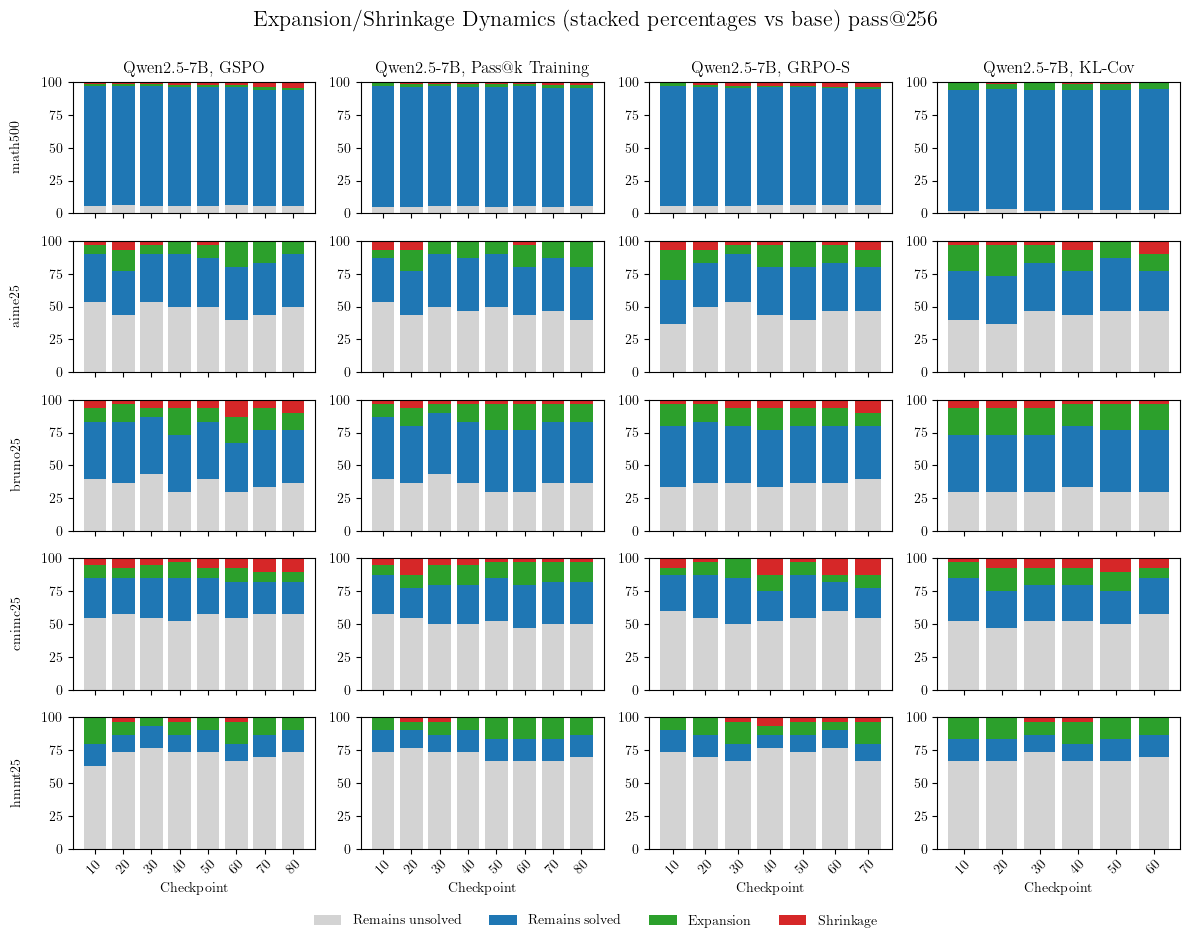

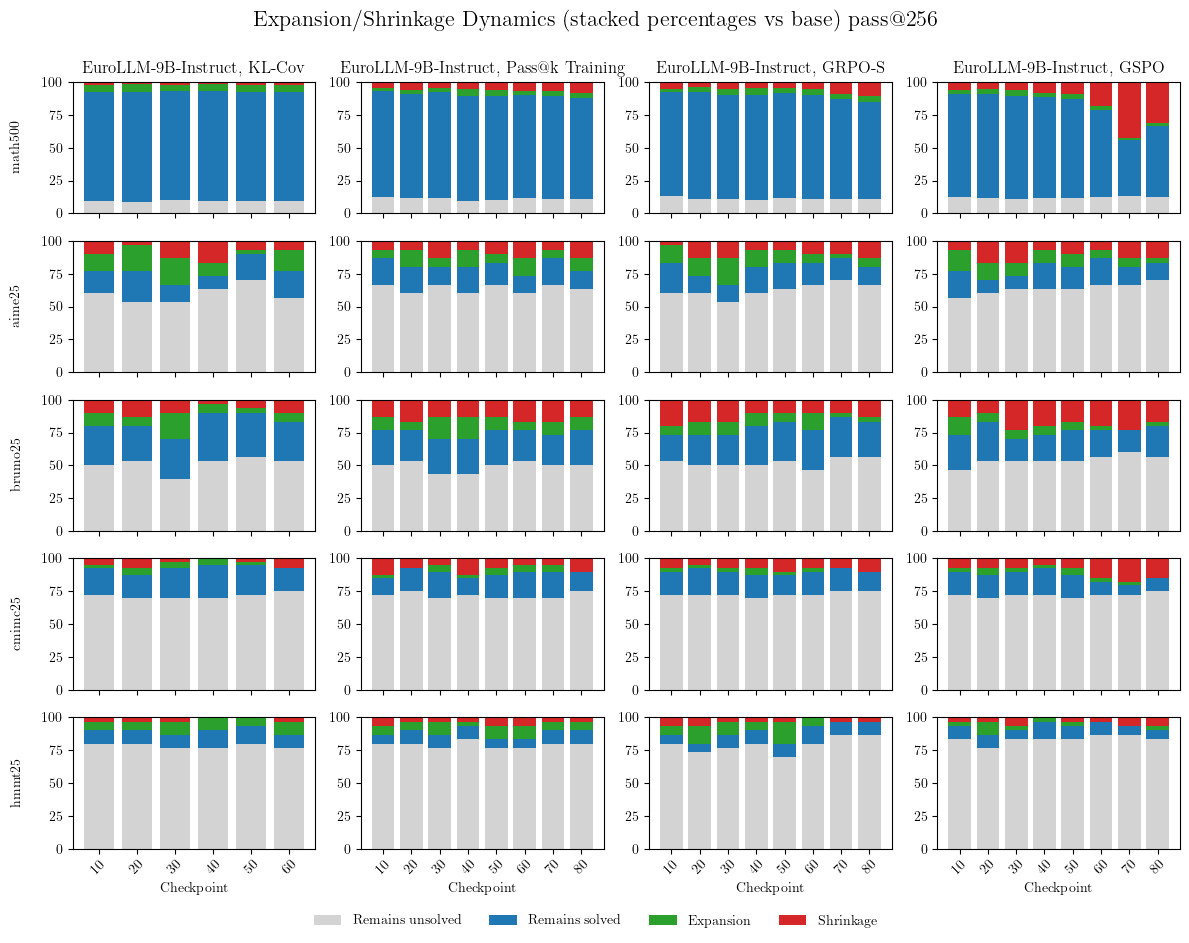

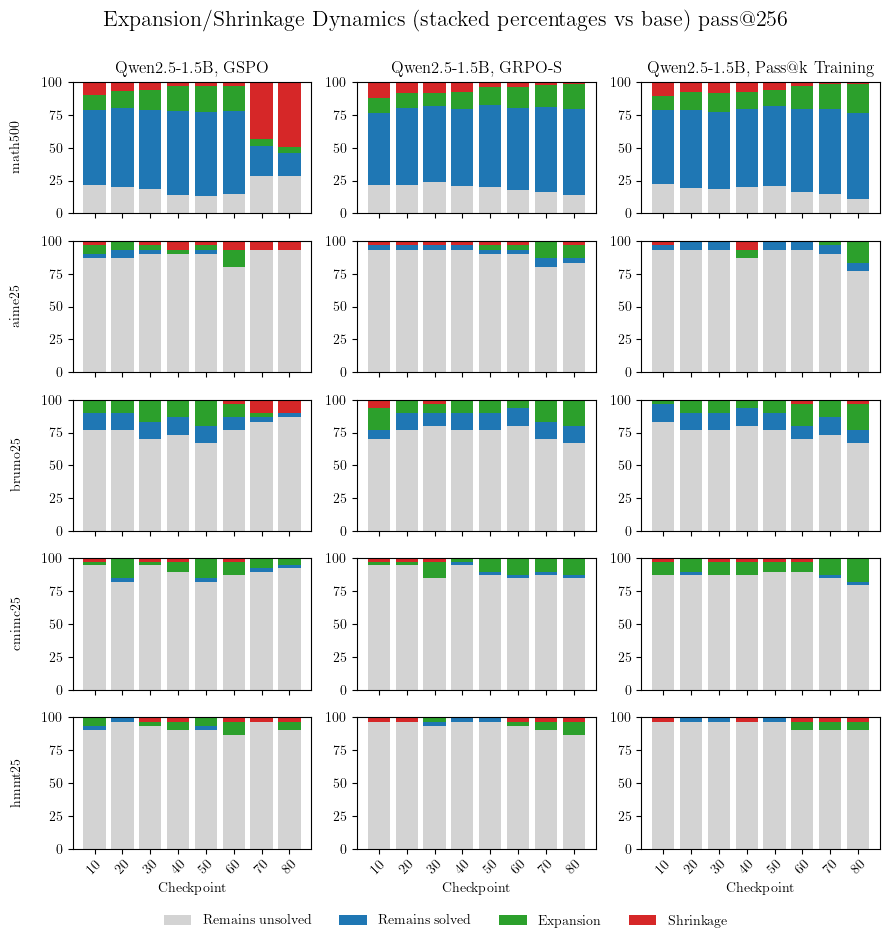

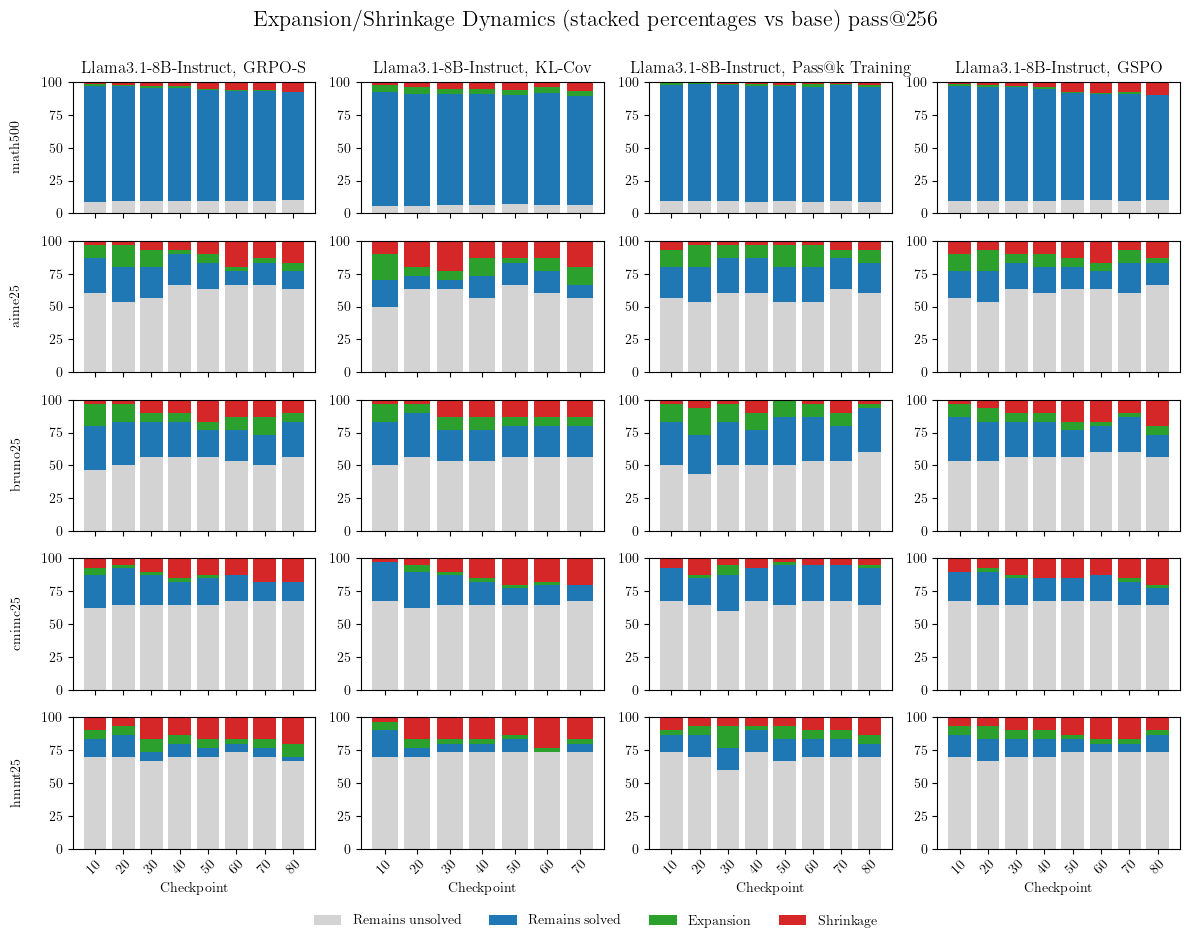

In [30]:
for m in models:
    pse = compute_PSE({k : v for k, v in passk.items() if m in k})
    plot_pse(pse)

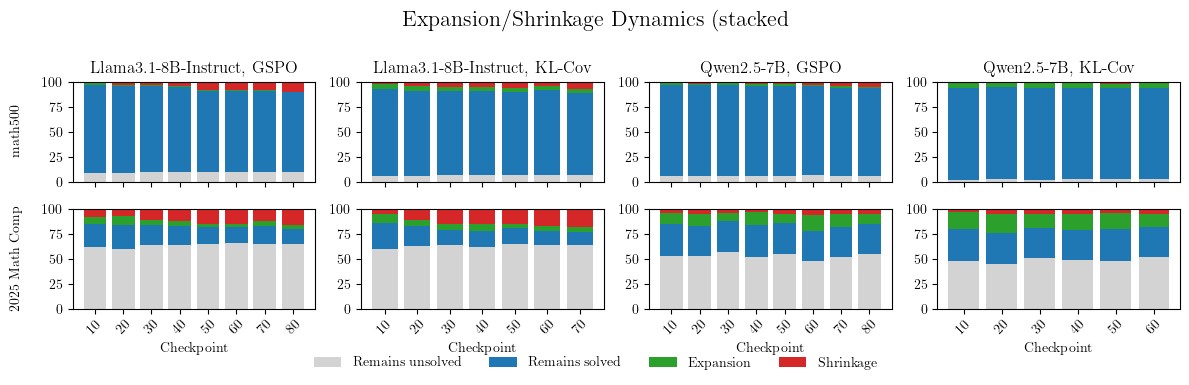

In [31]:
## subset of plots to show shrinkage
def plot_pse_math500_vs_others(subset: dict):
    """
    Same as plot_pse, but:
      - math500 is shown as its own row
      - all other datasets are aggregated into a single row
    """

    methods = sorted(list(subset.keys()))

    checkpoints = sorted(
        subset[methods[0]].keys(),
        key=lambda x: int(x)
    )

    # Collect dataset names from first method / checkpoint
    all_datasets = list(subset[methods[0]][checkpoints[0]].keys())

    has_math500 = "math500" in all_datasets
    other_datasets = [d for d in all_datasets if d != "math500"]

    row_labels = []
    if has_math500:
        row_labels.append("math500")
    if len(other_datasets) > 0:
        row_labels.append("2025 Math Comp")

    name_mapper = {
        "preservation_unsolved": "Remains unsolved",
        "preservation_solved": "Remains solved",
        "expansion": "Expansion",
        "shrinkage": "Shrinkage",
    }
    colors = {
        "preservation_unsolved": "lightgray",
        "preservation_solved": "tab:blue",
        "expansion": "tab:green",
        "shrinkage": "tab:red",
    }

    fig, axes = plt.subplots(
        ncols=len(methods),
        nrows=len(row_labels),
        sharex='col',
        figsize=(3 * len(methods), 2 * len(row_labels)),
    )

    # Make axes always 2D
    if len(row_labels) == 1:
        axes = axes[np.newaxis, :]
    if len(methods) == 1:
        axes = axes[:, np.newaxis]

    for col, method in enumerate(methods):
        checkpoints = sorted(
            subset[method].keys(),
            key=lambda x: int(x)
        )

        for row, row_name in enumerate(row_labels):
            ax = axes[row, col]
            bottoms = np.zeros(len(checkpoints))

            for metric in [
                "preservation_unsolved",
                "preservation_solved",
                "expansion",
                "shrinkage",
            ]:
                values = []

                for ckpt_idx, ckpt in enumerate(checkpoints):
                    if row_name == "math500":
                        stats = subset[method][ckpt]["math500"]["base"]
                        total = sum(stats.values())
                        v = stats[metric] / total if total > 0 else 0.0
                    else:
                        # Aggregate all non-math500 datasets
                        agg = {k: 0 for k in colors.keys()}
                        for d in other_datasets:
                            s = subset[method][ckpt][d]["base"]
                            for k in agg:
                                agg[k] += s[k]
                        total = sum(agg.values())
                        v = agg[metric] / total if total > 0 else 0.0

                    values.append(v)

                ax.bar(
                    checkpoints,
                    values,
                    bottom=bottoms,
                    color=colors[metric],
                    width=0.8,
                    label=name_mapper[metric] if (row == 0 and col == 0) else None,
                )
                bottoms += np.array(values)

            if row == 0:
                mo, me = method.split("__")
                ax.set_title(f"{model_name_mapper[mo]}, {method_name_mapper[me]}")

            if col == 0:
                ax.set_ylabel(row_name + "\n % pass@256")

            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, 25, 50, 75, 100])

            if row == len(row_labels) - 1:
                ax.set_xlabel("Checkpoint")
                ax.tick_params(axis="x", rotation=45)

    # Legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.suptitle(
        "Expansion/Shrinkage Dynamics (stacked % vs base) pass@256",
        fontsize=16,
        y=0.95,
    )
    fig.tight_layout(rect=[0, 0.05, 1, 0.95])

    models = set([m.split("__")[0] for m in methods])
    ms = set([m.split("__")[1] for m in methods])
    outfile = (
        f"pse_stacked_perc__math500_vs_others__"
        f"Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
    )

    fig.savefig(
        os.path.join(outcome_based_plotdir, outfile),
        format="pdf",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


predicate = lambda m : (m.split('__')[0] in ['qwen2.5_7b', 'llama_3.1_8b_instruct']) and (m.split('__')[1] in ['kl-cov', 'gspo'])
subset = pse = compute_PSE({k : v for k, v in passk.items() if predicate(k)})
plot_pse_math500_vs_others(subset)

In [32]:
def preprocess_pse(subset : dict):
    """
        Returns dicts of shape:
            1) expansion:
            
            methodX:
                [1, 0, 1, 0, ..., 1] (pass@256 of methodX = 1 & pass@256 of base=0)
            methodY
                [1, 0, 1, 0, ..., 1] (pass@256 of methodY = 1 & pass@256 of base=0)
            ...

            2) shrinkage:
            methodX:
                [1, 0, 0, 1, ..., 1] (pass@256 of methodX = 0 & pass@256 of base=1)
            methodY
                [1, 0, 1, 1, ..., 0] (pass@256 of methodY = 0 & pass@256 of base=1)
            ...
    """
    def get_last_index(keys) -> str:
        return str(sorted(list(map(int, list(keys))), reverse=True)[0])
    
    expansion, shrinkage = {}, {}
    for method in subset.keys():
        base_pass256 = np.concat(
            list(subset[method]['0'].values()), 
            axis=0
        )[:, -1].astype(bool)
        last_pass256 = np.concat(
            list(subset[method][get_last_index(subset[method].keys())].values()), 
            axis=0
        )[:, -1].astype(bool)

        e, s = ~base_pass256 & last_pass256, base_pass256 & ~last_pass256
        mo, me = method.split('__')
        pretty_name = f"{model_name_mapper[mo]}, {method_name_mapper[me]}"
        expansion[pretty_name] = e; shrinkage[pretty_name] = s

    # --- prune uninteresting indices ---
    # stack: shape (num_methods, num_questions)
    exp_stack = np.stack(list(expansion.values()), axis=0)
    shr_stack = np.stack(list(shrinkage.values()), axis=0)

    # expansion: drop questions never solved by any method
    exp_keep_mask = np.any(exp_stack, axis=0)

    # shrinkage: drop questions always solved by all methods
    # (i.e., no shrinkage occurs for any method)
    shr_keep_mask = np.any(shr_stack, axis=0)

    # apply masks
    for k in expansion:
        expansion[k] = expansion[k][exp_keep_mask]

    for k in shrinkage:
        shrinkage[k] = shrinkage[k][shr_keep_mask]

    return expansion, shrinkage

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import from_indicators, plot

def plot_upset(expansion, shrinkage, title_suffix):
    """
    Erstellt UpSet-Plots mit spezifischen Farben und Sortierung.
    Expansion: Light Green
    Shrinkage: Light Red
    """
    datasets = [
        (expansion, "Expansion (pass@256 Base=0, RL=1)", "#50B428", "expansion"), # Light Green
        (shrinkage, "Shrinkage (pass@256 Base=1, RL=0)", "#E3615F", "shrinkage")   # Light Red
    ]

    for data, title, color, handle in datasets:
        if not data:
            continue
            
        df = pd.DataFrame(data)
        upset_data = from_indicators(indicators=df.columns, data=df)
        fig = plt.figure(figsize=(5, 4))
        
        # sort_by='cardinality' sortiert nach der Größe der Schnittmengen
        plot(upset_data, 
             fig=fig, 
             facecolor=color, 
             sort_by='cardinality', 
             show_counts=True)
        
        fig.suptitle(title + title_suffix, fontsize=14)
        plt.show()
        
        # have to use keys of the method_mapper, as texstudio doesn't like "@" in the path to figure.
        inverse_method_name_mapper = {v : k for k, v in method_name_mapper.items()}
        inverse_model_name_mapper = {v : k for k, v in model_name_mapper.items()}

        # Save as vector PDF
        methods = set(expansion.keys())
        models = set([m.split(', ')[0]for m in methods])
        ms = set([m.split(', ')[1]for m in methods])

        ms, models = list(map(inverse_method_name_mapper.__getitem__, ms)), \
                            list(map(inverse_model_name_mapper.__getitem__, models))
        
        outfile = f"UpSet_{handle}_Models:{'--'.join(models)}__Methods:{'--'.join(ms)}.pdf"
        fig.savefig(os.path.join(outcome_based_plotdir, outfile), format="pdf", bbox_inches="tight")
        plt.show()
        plt.close(fig)

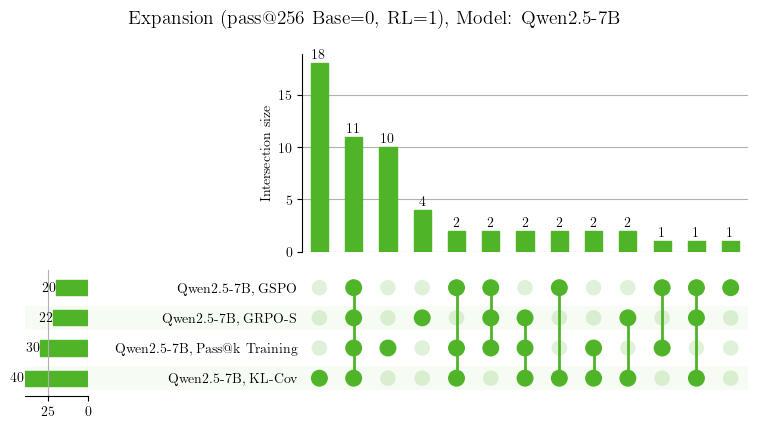

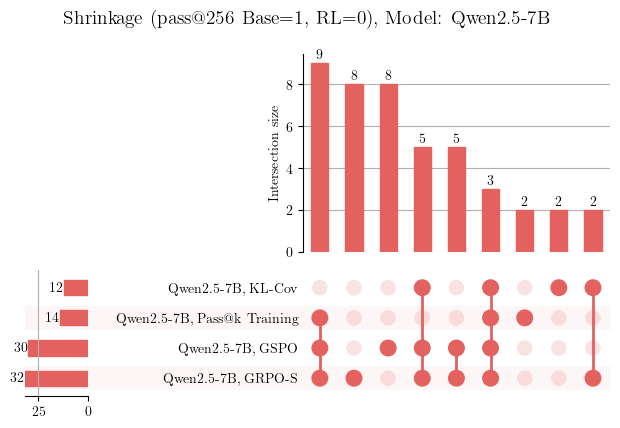

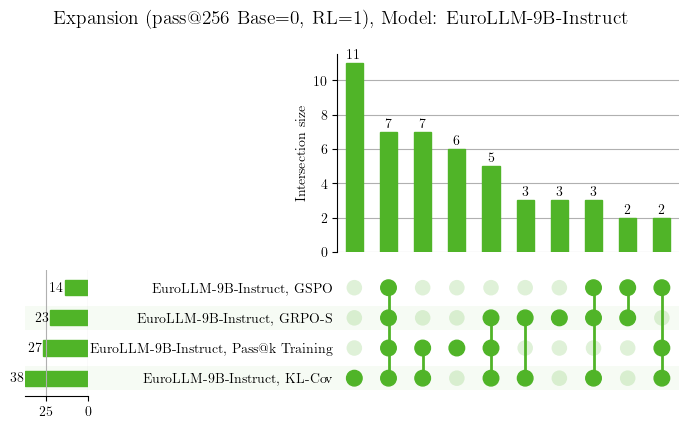

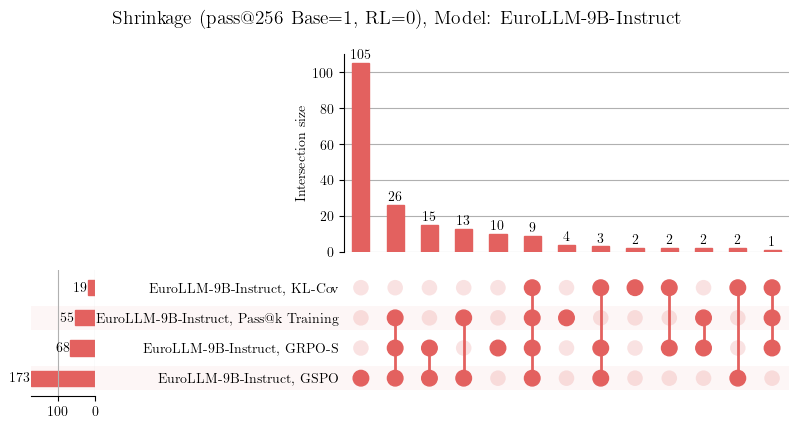

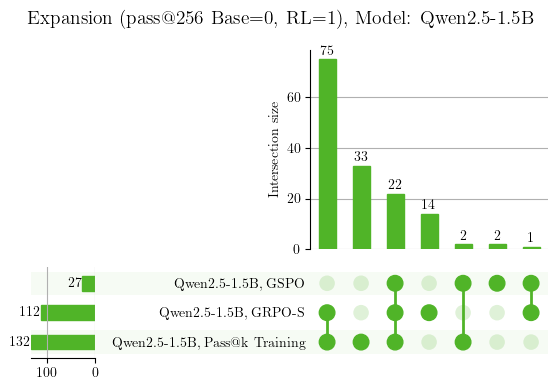

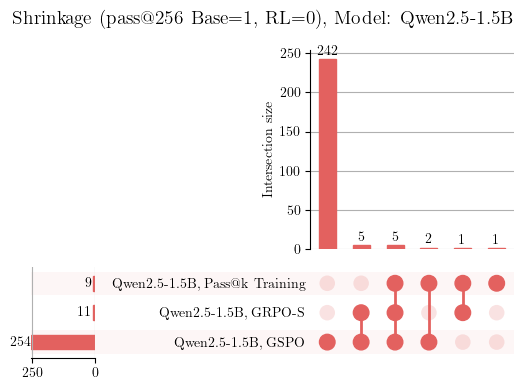

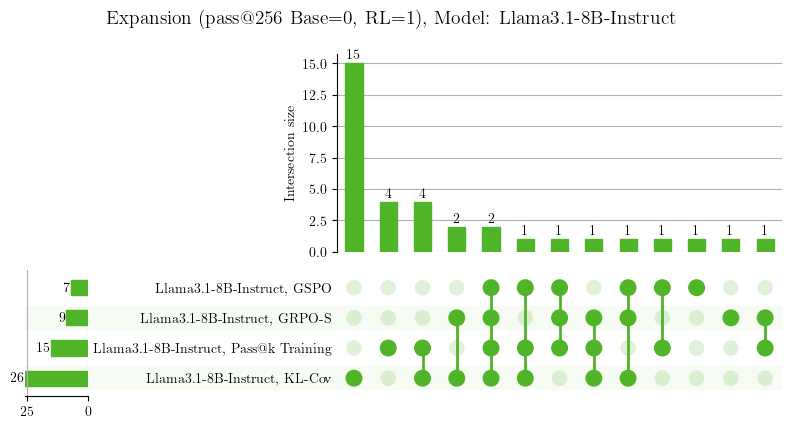

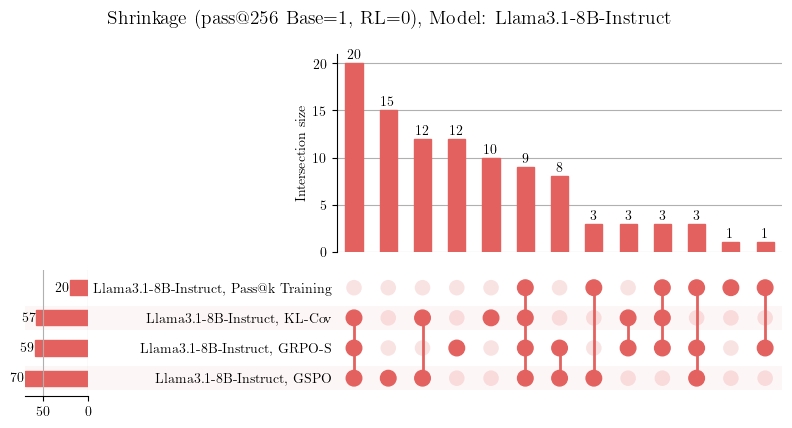

In [34]:
import warnings
warnings.filterwarnings("ignore")
for m in models:
    subset = {k : v for k ,v in passk.items() if m in k}
    expansion, shrinkage = preprocess_pse(subset)
    title = f", Model: {model_name_mapper[m]}"
    plot_upset(expansion, shrinkage, title_suffix=title)

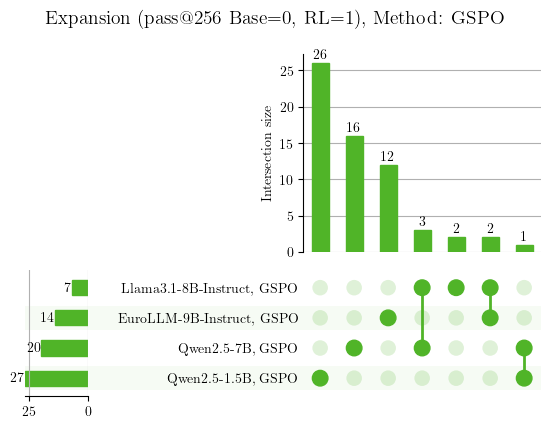

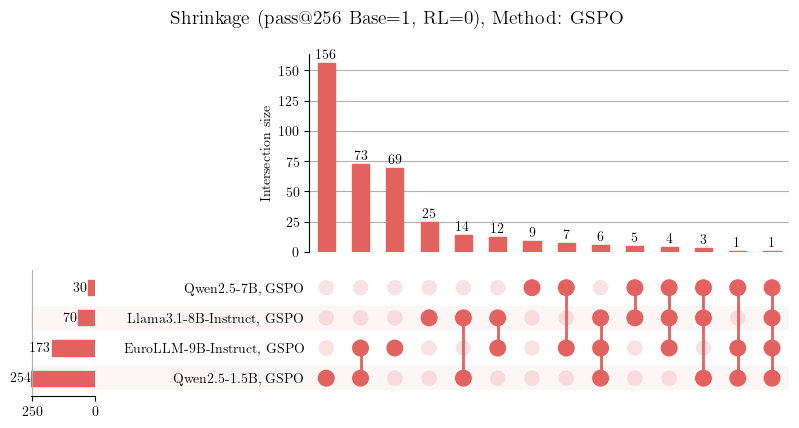

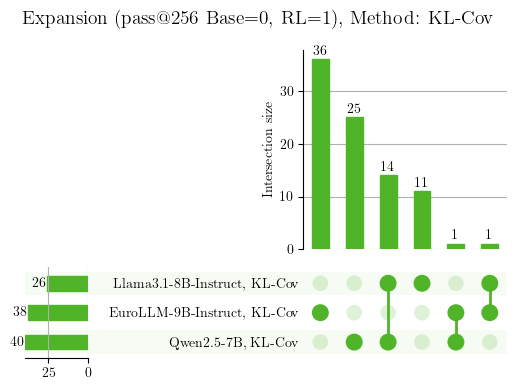

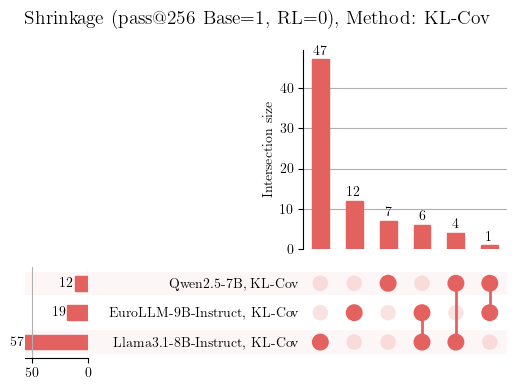

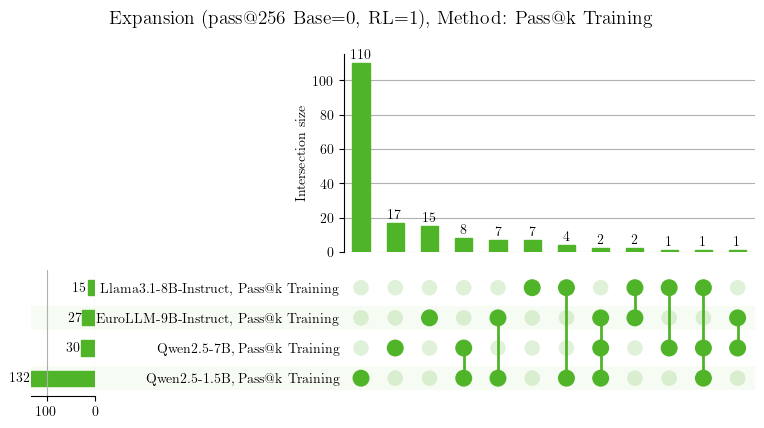

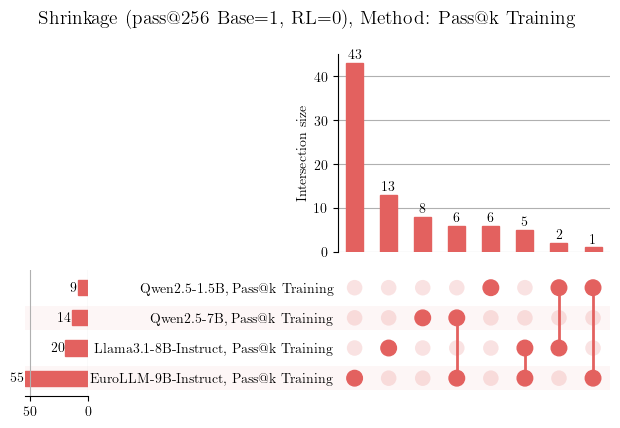

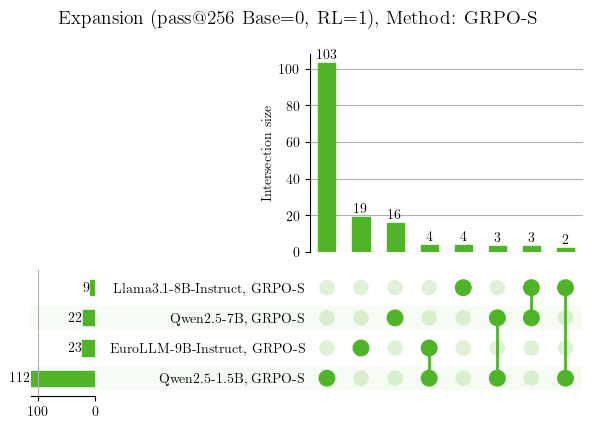

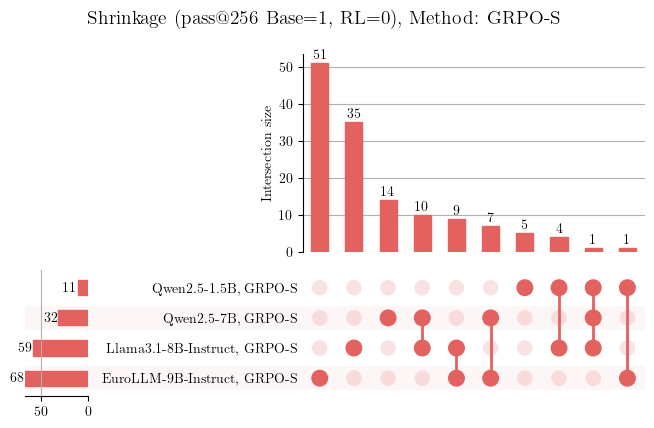

In [35]:
for m in methods:
    subset = {k : v for k ,v in passk.items() if m in k}
    expansion, shrinkage = preprocess_pse(subset)
    title = f", Method: {method_name_mapper[m]}"
    plot_upset(expansion, shrinkage, title_suffix=title)